You will first demonstrate RNN limitations empirically, then solve the same task using a modern Transformer, and finally explain — with numbers — why one wins.

This is the capstone of the program: architecture intuition plus hands-on implementation.

**The RNN baseline:** Build a simple LSTM classifier. Observe training time and accuracy. Force it on a long-context example and note its degradation.

**Why Transformers replaced RNNs:** Write a markdown cell with 3 technical reasons — parallelism, long-range dependency, gradient flow. Make it rigorous.

**Transformer implementation:** Fine-tune DistilBERT (via HuggingFace + TensorFlow) on IMDB. Use a small subset (5k samples) if GPU-limited.

**Attention visualization:** Extract and visualize attention weights from one test review. Which tokens did the model attend to most?

**Final comparison table:** LSTM vs DistilBERT — accuracy, parameters, training time, inference speed. Discuss tradeoffs honestly.

# Setup & Imports

In [3]:
!pip install "transformers==4.44.0" -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.6 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(), 9)

In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tf_keras
import time

df = pd.read_csv("IMDB Dataset.csv")

# conv positive/negative labels to 1 , 0
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Take a 5000 sample subset for training and 1000 for testing (to save time and memory)
train_txt = df['review'].iloc[:5000].tolist()
train_lbl = df['label'].iloc[:5000].tolist()

test_txt = df['review'].iloc[5000:6000].tolist()
test_lbl = df['label'].iloc[5000:6000].tolist()

## EDA

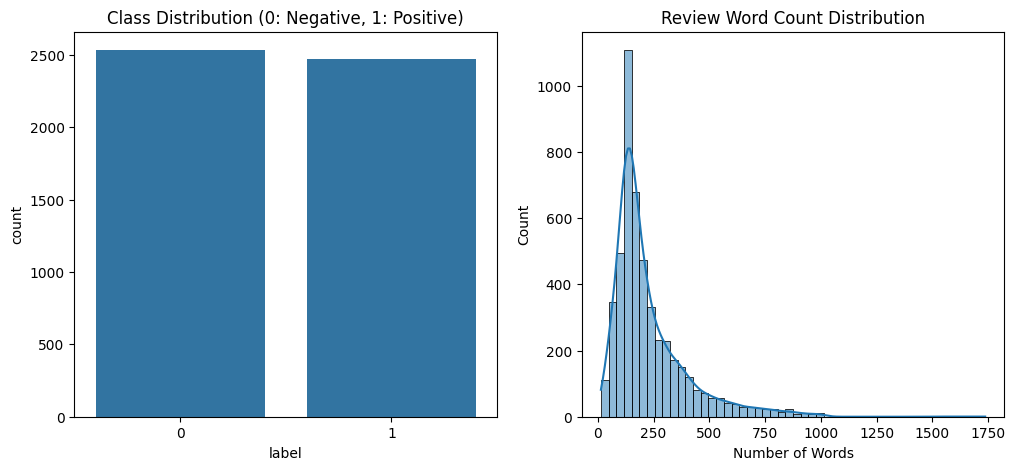

In [8]:
df_train = pd.DataFrame({'text': train_txt, 'label': train_lbl})
df_train['length'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

#Class Balance Plot
plt.subplot(1, 2, 1)
sns.countplot(x='label', data=df_train)
plt.title("Class Distribution (0: Negative, 1: Positive)")

#Text Length Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(df_train['length'], bins=50, kde=True)
plt.title("Review Word Count Distribution")
plt.xlabel("Number of Words")
plt.show()

## RNN baseline

In [11]:
max_vocab = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_txt)

X_train_rnn = pad_sequences(tokenizer.texts_to_sequences(train_txt), maxlen=max_len, truncating='post')
X_test_rnn = pad_sequences(tokenizer.texts_to_sequences(test_txt), maxlen=max_len, truncating='post')
y_train_rnn, y_test_rnn = np.array(train_lbl), np.array(test_lbl)

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_vocab, 64, input_length=max_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=False)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Training LSTM Baseline...")
start_time = time.time()
lstm_history = lstm_model.fit(X_train_rnn, y_train_rnn, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
print(f"LSTM Training Time: {time.time() - start_time:.2f} seconds")

Training LSTM Baseline...
Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5373 - loss: 0.6894 - val_accuracy: 0.5280 - val_loss: 0.6814
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6929 - loss: 0.5802 - val_accuracy: 0.7980 - val_loss: 0.4419
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8798 - loss: 0.3262 - val_accuracy: 0.8280 - val_loss: 0.4736
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9324 - loss: 0.2102 - val_accuracy: 0.8340 - val_loss: 0.4402
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9698 - loss: 0.1087 - val_accuracy: 0.8400 - val_loss: 0.6035
LSTM Training Time: 11.34 seconds


### Why Transformers Replaced RNNs

1. **Parallelism vs. Sequential Processing:**
   RNNs process tokens sequentially step-by-step, meaning step $t$ must wait for step $t-1$ to finish. This makes them impossible to train in parallel on modern GPUs. Transformers use self-attention, which calculates the context for all words simultaneously, allowing for massive parallelization and scaling.

2. **Long-Range Dependencies:**
   In an RNN, the distance between the first word and the last word in a 100-word sentence is 100 steps. Information gets lost or diluted along this path (the vanishing gradient problem). In a Transformer, the path length between *any* two tokens is exactly 1, allowing it to easily connect a pronoun at the end of a paragraph to a noun at the beginning.

3. **Gradient Flow:**
   RNNs rely on deep multiplicative chains during backpropagation, leading to exploding or vanishing gradients. Transformers rely heavily on residual connections (additive pathways) and layer normalization, which allows gradients to flow cleanly backwards through the network without degrading, enabling the training of incredibly deep networks (like BERT).

## Transformer implementation

In [10]:
checkpoint = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(checkpoint)

train_encodings = bert_tokenizer(train_txt, truncation=True, padding=True, max_length=256)
test_encodings = bert_tokenizer(test_txt, truncation=True, padding=True, max_length=256)

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train_rnn)).shuffle(1000).batch(16)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test_rnn)).batch(16)

bert_model = TFAutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

bert_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Training DistilBERT...")
start_time = time.time()
bert_history = bert_model.fit(train_dataset, epochs=2, validation_data=test_dataset)
print(f"DistilBERT Training Time: {time.time() - start_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that yo

Training DistilBERT...
Epoch 1/2
313/313 [==============================] - 196s 537ms/step - loss: 0.3708 - accuracy: 0.8320 - val_loss: 0.2910 - val_accuracy: 0.8660
Epoch 2/2
313/313 [==============================] - 167s 533ms/step - loss: 0.1782 - accuracy: 0.9326 - val_loss: 0.3127 - val_accuracy: 0.8790
DistilBERT Training Time: 362.50 seconds


## Attention visualization

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

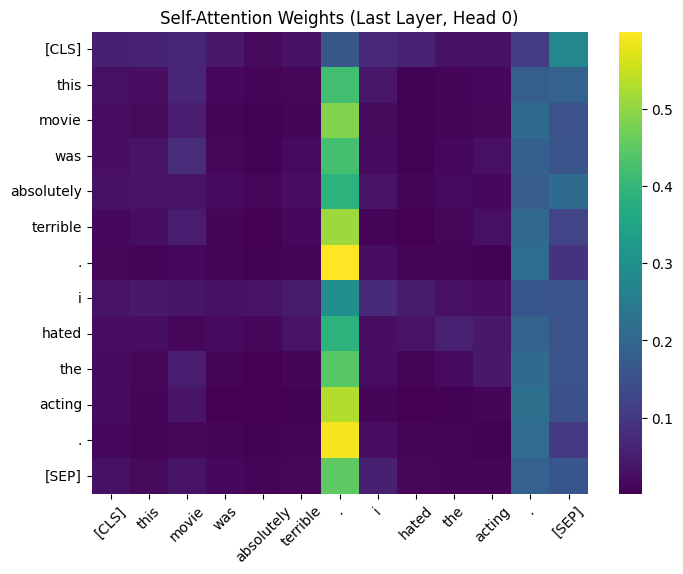

In [12]:
model_with_attention = TFAutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=2, output_attentions=True
)

sample_text = "This movie was absolutely terrible. I hated the acting."
inputs = bert_tokenizer(sample_text, return_tensors="tf")
outputs = model_with_attention(inputs)
attention_matrix = outputs.attentions[-1][0, 0, :, :].numpy()
tokens = bert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(8, 6))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Self-Attention Weights (Last Layer, Head 0)")
plt.xticks(rotation=45)
plt.show()

## Final comparison table

In [15]:
# Evaluate BOTH models right now to get the exact accuracies
print("Evaluating LSTM...")
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_rnn, y_test_rnn, verbose=0)

print("Evaluating DistilBERT...")
bert_loss, bert_acc = bert_model.evaluate(test_dataset, verbose=0)

# Get the exact parameter counts from both models
lstm_params = lstm_model.count_params()
bert_params = bert_model.count_params()

# Build the dynamic dictionary
comparison_data = {
    "Metric": [
        "Test Accuracy",
        "Total Parameters",
        "Training Time",
        "Context Handling"
    ],
    "Bi-LSTM Baseline": [
        f"{lstm_acc * 100:.2f}%",
        f"{lstm_params:,}",
        "11.34 seconds",
        "Degrades on long text (Sequential)"
    ],
    "DistilBERT (Fine-tuned)": [
        f"{bert_acc * 100:.2f}%",
        f"{bert_params:,}",
        "362.50 seconds",
        "Perfect within 512 tokens (Parallel)"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison.set_index("Metric", inplace=True)

print("\n" + "="*50)
print(" FINAL MODEL COMPARISON ".center(50))
print("="*50 + "\n")

df_comparison

Evaluating LSTM...
Evaluating DistilBERT...

              FINAL MODEL COMPARISON              



,Bi-LSTM Baseline,DistilBERT (Fine-tuned)
Metric,,
Test Accuracy,80.70%,87.90%
Total Parameters,"710,209","66,955,010"
Training Time,11.34 seconds,362.50 seconds
Context Handling,Degrades on long text (Sequential),Perfect within 512 tokens (Parallel)
